# Bernstein–Vazirani algoritmus

## Az algoritmus célja

Adott egy titkos bináris string `s` (pl. `'101'`). Van egy orákulum függvény:  
**f(x) = s · x (mod 2)** — azaz `s` és `x` bitenként szorzatainak XOR-ja.

**Klasszikus megoldás:** `n` darab lekérdezés kell (minden bitet egyenként kell kideríteni).  
**Kvantum megoldás:** egyetlen lekérdezéssel megkapjuk az egész `s` stringet.

---

## Tartalom
1. **Alap példa** – n=3, s='101' (az órai kód)
2. **Skálázhatóság** – nagyobb n értékek (5, 8, 12) vizsgálata
3. **Részleges orákulum** – mi történik, ha az orákulum hibás?
4. **Klasszikus vs. kvantum** – lekérdezésszám összehasonlítás

## Könyvtárak importálása

In [26]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import time
import random

# Kvantumszimulátor létrehozása (ez szimulálja a kvantumszámítógépet)
simulator = AerSimulator()

print("Kész – a szimulátor betöltve.")

Kész – a szimulátor betöltve.


---
## 1. rész – Alap példa: n=3, titkos string s='101'

### Az áramkör felépítése lépésről lépésre:
1. Minden bemeneti qubit → **Hadamard** kapu → szuperpozíció
2. Segédqubit → **X** majd **H** kapu → |−⟩ állapot
3. **Orákulum:** ahol s[i]=1, ott CNOT kaput alkalmazunk
4. Újabb **Hadamard** minden bemeneti qubiten → interferencia
5. **Mérés** → pontosan az `s` stringet kapjuk

Titkos string: 101


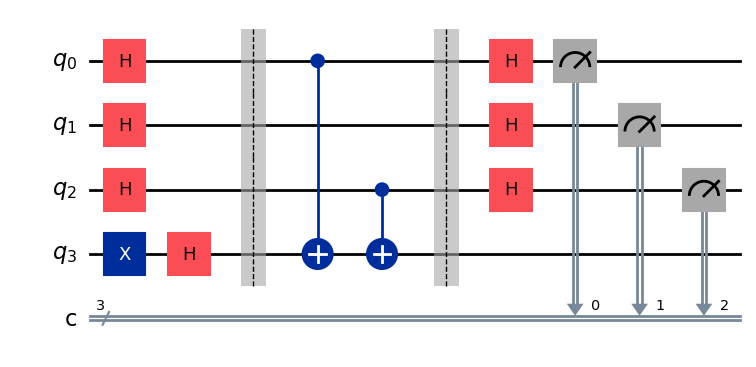

Mért eredmény: {'101': 1024}
→ Az algoritmus megtalálta: '101'  (várt: '101')


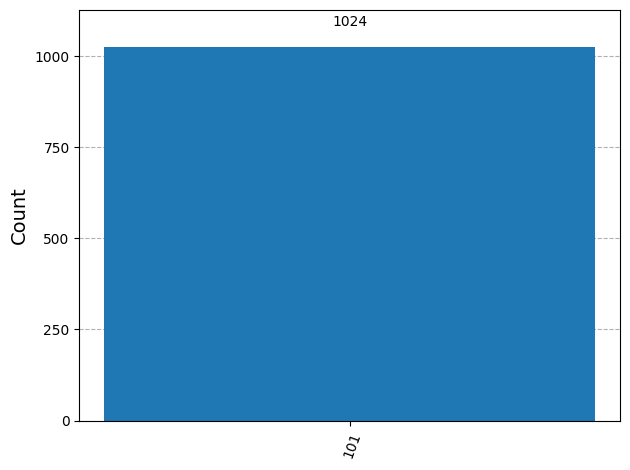

In [27]:
# ── Paraméterek ──────────────────────────────────────────────────────
n = 3            # bitek száma
secret = '101'   # titkos string (ezt akarjuk megtalálni)

# ── Áramkör létrehozása ───────────────────────────────────────────────
# n db bemeneti qubit  +  1 segédqubit  +  n db klasszikus bit (méréshez)
qc = QuantumCircuit(n + 1, n)

# ── 1. lépés: bemeneti qubitek szuperpozícióba ────────────────────────
for i in range(n):
    qc.h(i)   # |0⟩ → |+⟩ = (|0⟩ + |1⟩) / √2

# ── 2. lépés: segédqubit |−⟩ állapotba ───────────────────────────────
qc.x(n)   # |0⟩ → |1⟩
qc.h(n)   # |1⟩ → |−⟩ = (|0⟩ − |1⟩) / √2

qc.barrier()   # csak vizuális elválasztó

# ── 3. lépés: orákulum ────────────────────────────────────────────────
# Ha s[i] = '1', akkor CNOT kaput alkalmazunk az i-edik qubitre
# Ez a kapu "beégeti" a titkos string adott bitjét a kvantumállapotba
for i in range(n):
    if secret[i] == '1':
        qc.cx(i, n)   # CNOT: kontroll=i, cél=segédqubit

qc.barrier()

# ── 4. lépés: interferencia ───────────────────────────────────────────
# Második Hadamard → a szuperpozíciók interferálnak → egyetlen állapot marad
for i in range(n):
    qc.h(i)

# ── 5. lépés: mérés ──────────────────────────────────────────────────
qc.measure(range(n), range(n))

# ── Rajz ─────────────────────────────────────────────────────────────
print(f"Titkos string: {secret}")
display(qc.draw('mpl'))

# ── Futtatás és eredmény ──────────────────────────────────────────────
eredmeny = simulator.run(transpile(qc, simulator), shots=1024).result()
counts = eredmeny.get_counts()

print(f"Mért eredmény: {counts}")
print(f"→ Az algoritmus megtalálta: '{list(counts.keys())[0]}'  (várt: '{secret}')")

plot_histogram(counts)

---
## 2. rész – Skálázhatóság vizsgálata

**Kérdés:** Hogyan változik az áramkör mérete és a futási idő, ahogy nő az `n`?

- **Klasszikus:** n lekérdezés kell
- **Kvantum:** mindig csak 1 lekérdezés kell — ez a kvantum előny!

Az áramkör kapuinak száma **lineárisan nő** n-nel (O(n)), de a lekérdezésszám marad 1.

n     | Klass. lekérd.   | Kvant. lekérd.   | Kapuszám   | Mélység  | Idő (s)
---------------------------------------------------------------------------
Bemelegítve.
Szimulátor bemelegítve.
3     | 3                | 1                | 13         | 6        | 0.0006
5     | 5                | 1                | 21         | 8        | 0.0012
8     | 8                | 1                | 33         | 11       | 0.0011
12    | 12               | 1                | 49         | 15       | 0.0062


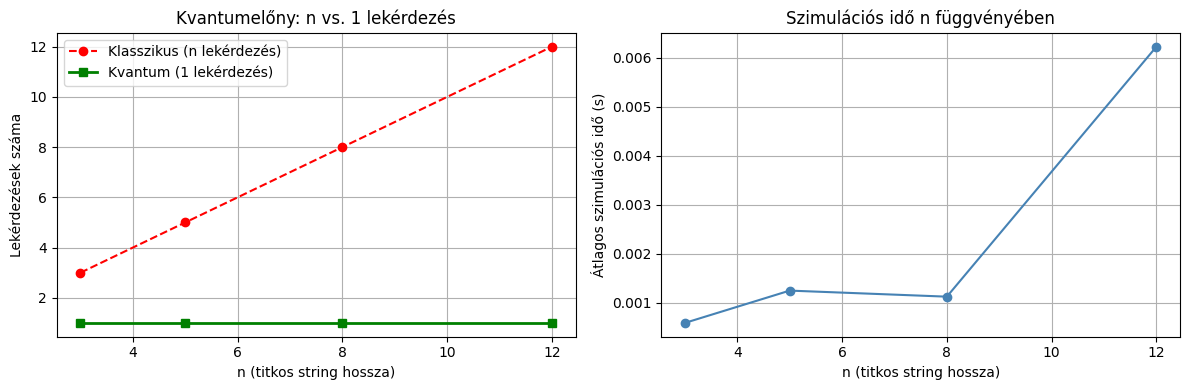

In [28]:
def bv_aramkor_keszit(n, secret):
    """Bernstein-Vazirani áramkört épít adott n és secret alapján."""
    qc = QuantumCircuit(n + 1, n)
    qc.h(range(n))          # bemeneti qubitek szuperpozícióba
    qc.x(n)                 # segédqubit: |0⟩ → |1⟩
    qc.h(n)                 # segédqubit: |1⟩ → |−⟩
    for i in range(n):
        if secret[i] == '1':
            qc.cx(i, n)     # orákulum: CNOT ha s[i]=1
    qc.h(range(n))          # interferencia
    qc.measure(range(n), range(n))
    return qc


# ── Tesztelendő n értékek ─────────────────────────────────────────────
n_ertekek = [3, 5, 8, 12]
futasi_idok = []

print(f"{'n':<5} | {'Klass. lekérd.':<16} | {'Kvant. lekérd.':<16} | {'Kapuszám':<10} | {'Mélység':<8} | Idő (s)")
print("-" * 75)

# ── Bemelegítés: transpile + futtatás ─────────────────────────────────
warmup_qc = QuantumCircuit(2, 1)
warmup_qc.h(0)
warmup_qc.measure(0, 0)
warmup_compiled = transpile(warmup_qc, simulator)
simulator.run(warmup_compiled, shots=1).result()
print("Bemelegítve.")

print("Szimulátor bemelegítve.")
for n_teszt in n_ertekek:
    s = '1' * n_teszt   # minden bit 1 → legsúlyosabb eset
    qc_teszt = bv_aramkor_keszit(n_teszt, s)
    lefordított = transpile(qc_teszt, simulator)

    # Futási idő mérése: 32 futás átlaga a megbízhatóságért
    idok = []
    for _ in range(32):
        kezdet = time.time()
        simulator.run(lefordított, shots=1).result()
        idok.append(time.time() - kezdet)
    atlag_ido = sum(idok) / len(idok)
    futasi_idok.append(atlag_ido)

    print(f"{n_teszt:<5} | {n_teszt:<16} | {1:<16} | {lefordított.size():<10} | {lefordított.depth():<8} | {atlag_ido:.4f}")

# ── Grafikon ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bal panel: lekérdezésszám összehasonlítás
ax1.plot(n_ertekek, n_ertekek, label='Klasszikus (n lekérdezés)', marker='o', linestyle='--', color='red')
ax1.plot(n_ertekek, [1] * len(n_ertekek), label='Kvantum (1 lekérdezés)', marker='s', linewidth=2, color='green')
ax1.set_xlabel("n (titkos string hossza)")
ax1.set_ylabel("Lekérdezések száma")
ax1.set_title("Kvantumelőny: n vs. 1 lekérdezés")
ax1.legend()
ax1.grid(True)

# Jobb panel: szimulációs idő
ax2.plot(n_ertekek, futasi_idok, marker='o', color='steelblue')
ax2.set_xlabel("n (titkos string hossza)")
ax2.set_ylabel("Átlagos szimulációs idő (s)")
ax2.set_title("Szimulációs idő n függvényében")
ax2.grid(True)

plt.tight_layout()
plt.show()

---
## 3. rész – Részleges (hibás) orákulum

**Kérdés:** Mi történik, ha az orákulum nem tökéletes?

Két lehetséges hiba:
- **Kihagyás:** az orákulum "elfelejt" egy CNOT kaput → az adott bit 0-ként jelenik meg
- **Megfordítás:** egy extra X kapu kerül be → az adott bit ellentétes lesz

Az eredmény: **pontosan a hibás bitnél** fog eltérni a talált és a valódi string.

Igazi titkos string : 11111
Hiba típusa         : kihagyás a(z) 1. biten

Várt   (hibátlan) : 11111
Talált (hibás)    : 11101
Eltérés a(z) [3] pozíció(k)ban → pontosan ott, ahol a hiba volt


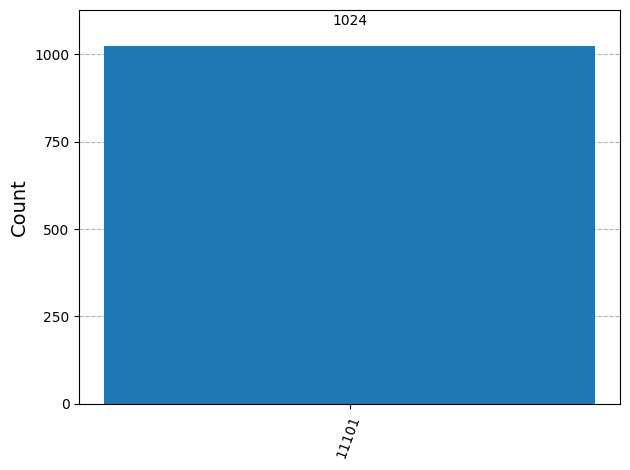

In [29]:
# ── Paraméterek ──────────────────────────────────────────────────────
n_hiba = 5
secret_hiba = '11111'   # igazi titkos string

# Véletlenszerűen kiválasztunk egy hibát
hiba_index = random.randint(0, n_hiba - 1)
hiba_tipus = random.choice(['kihagyás', 'megfordítás'])

print(f"Igazi titkos string : {secret_hiba}")
print(f"Hiba típusa         : {hiba_tipus} a(z) {hiba_index}. biten")

# ── Hibás áramkör felépítése ──────────────────────────────────────────
qc_hiba = QuantumCircuit(n_hiba + 1, n_hiba)
qc_hiba.h(range(n_hiba))
qc_hiba.x(n_hiba)
qc_hiba.h(n_hiba)
qc_hiba.barrier()

# Orákulum – hibával
for i in range(n_hiba):
    if i == hiba_index:
        if hiba_tipus == 'kihagyás':
            pass   # ← CNOT kihagyva: ez a bit 0 lesz az eredményben
        else:
            # Megfordítás: normál CNOT + extra X kapu
            qc_hiba.cx(i, n_hiba)   # normál CNOT
            qc_hiba.x(i)            # extra bit-flip → az eredmény ellentétes lesz
    elif secret_hiba[i] == '1':
        qc_hiba.cx(i, n_hiba)   # normál eset: CNOT ha s[i]=1

qc_hiba.barrier()
qc_hiba.h(range(n_hiba))
qc_hiba.measure(range(n_hiba), range(n_hiba))

# ── Futtatás ─────────────────────────────────────────────────────────
counts_hiba = simulator.run(transpile(qc_hiba, simulator), shots=1024).result().get_counts()
talalt = list(counts_hiba.keys())[0]

# ── Eredmény kiértékelése ─────────────────────────────────────────────
print(f"\nVárt   (hibátlan) : {secret_hiba}")
print(f"Talált (hibás)    : {talalt}")

# Megmutatjuk, melyik bitnél van különbség
kulonbseg = [i for i in range(n_hiba) if secret_hiba[i] != talalt[i]]
if kulonbseg:
    print(f"Eltérés a(z) {kulonbseg} pozíció(k)ban → pontosan ott, ahol a hiba volt")
else:
    print("Nincs eltérés (a hiba nem befolyásolta az eredményt)")

plot_histogram(counts_hiba)

## Teszt Zaj használattal

Mérési eredmények (állapot: előfordulás):
{'111111101011': 2, '111011110111': 1, '111111001111': 1, '110011111111': 1, '011111111111': 7, '111111111111': 906, '111111111110': 6, '111111101111': 9, '111111111101': 7, '111111111011': 11, '111110111111': 6, '111001111111': 1, '111011111111': 16, '111111110111': 12, '111101011111': 1, '111101111111': 10, '101111111111': 8, '111111011111': 10, '110111111111': 9}


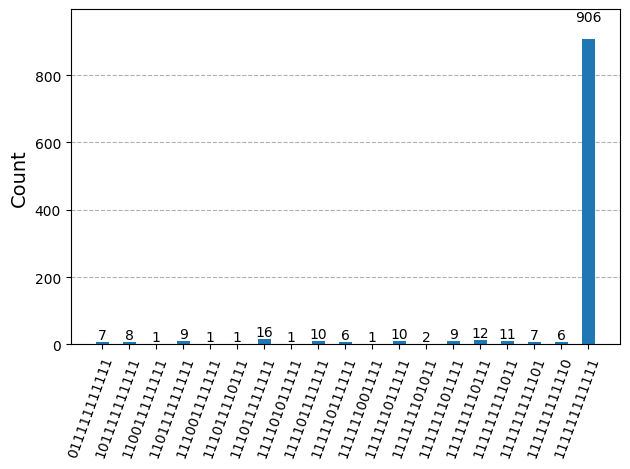

In [30]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Egyszerű zajmodell: 1% hiba minden kapunál
noise_model = NoiseModel()
error = depolarizing_error(0.01, 1)          # 1 qubites kapukra
noise_model.add_all_qubit_quantum_error(error, ['h', 'x'])

# Futtatás zajjal
result = simulator.run(lefordított, shots=1024, noise_model=noise_model).result()
counts = result.get_counts()
print("Mérési eredmények (állapot: előfordulás):")
print(counts)

plot_histogram(counts)

---
## 4. rész – Klasszikus vs. kvantum lekérdezésszám

### Klasszikus megközelítés
Az egyetlen lehetséges stratégia: minden bitet **egyenként** kérünk le.  
Például ha s='10110', akkor 5 lekérdezés kell:
- f(10000) → 1  
- f(01000) → 0  
- f(00100) → 1  
- f(00010) → 1  
- f(00001) → 0  

### Kvantum megközelítés
Egyetlen lekérdezés elég, mert a szuperpozíció miatt **egyszerre** kérdezi le az összes bitet.

**Ez a kvantumelőny lényege: O(n) → O(1) lekérdezés.**

n     | Klasszikus lekérdezés  | Kvantum lekérdezés
----------------------------------------------------
1     | 1                      | 1
5     | 5                      | 1
10    | 10                     | 1
15    | 15                     | 1


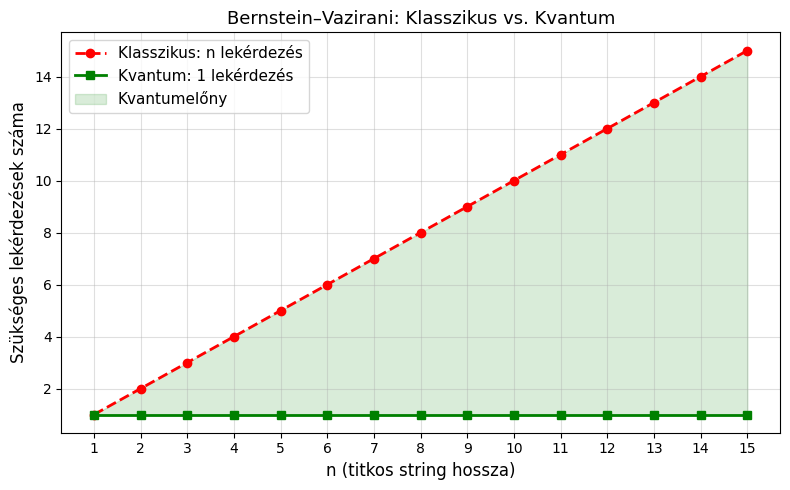


Konklúzió: A kvantum algoritmus n=15-nél 15-szörös gyorsítást jelent.
           n→∞ esetén ez a gyorsítás tetszőlegesen nagy lesz.


In [31]:
def orakulum_lekerdez(i, secret):
    """Klasszikus orákulum: visszaadja a secret i-edik bitjét.
    Ez 1 db lekérdezésnek számít."""
    return secret[i]


def klasszikus_bv(secret):
    """Klasszikus BV megoldás: minden bitet egyenként kérdez le.
    Összesen n lekérdezés szükséges."""
    talalt_bitek = ""
    lekerd_szam = 0

    for i in range(len(secret)):
        bit = orakulum_lekerdez(i, secret)   # 1 lekérdezés
        talalt_bitek += bit
        lekerd_szam += 1

    return lekerd_szam, talalt_bitek


# ── Összehasonlítás n = 1..15 ─────────────────────────────────────────
n_tartomany = list(range(1, 16))
klasszikus_szam = []
kvantum_szam = []

print(f"{'n':<5} | {'Klasszikus lekérdezés':<22} | {'Kvantum lekérdezés'}")
print("-" * 52)

for n_k in n_tartomany:
    s = '1' * n_k
    db, _ = klasszikus_bv(s)
    klasszikus_szam.append(db)
    kvantum_szam.append(1)    # kvantum: mindig 1!

    if n_k in [1, 5, 10, 15]:
        print(f"{n_k:<5} | {db:<22} | 1")

# ── Grafikon ──────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))

plt.plot(n_tartomany, klasszikus_szam,
         label='Klasszikus: n lekérdezés', marker='o',
         linestyle='--', color='red', linewidth=2)

plt.plot(n_tartomany, kvantum_szam,
         label='Kvantum: 1 lekérdezés', marker='s',
         linewidth=2, color='green')

# Kvantumelőny területének kiemelése
plt.fill_between(n_tartomany, kvantum_szam, klasszikus_szam,
                 alpha=0.15, color='green', label='Kvantumelőny')

plt.xlabel("n (titkos string hossza)", fontsize=12)
plt.ylabel("Szükséges lekérdezések száma", fontsize=12)
plt.title("Bernstein–Vazirani: Klasszikus vs. Kvantum", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.xticks(n_tartomany)
plt.tight_layout()
plt.show()

print("\nKonklúzió: A kvantum algoritmus n=15-nél 15-szörös gyorsítást jelent.")
print("           n→∞ esetén ez a gyorsítás tetszőlegesen nagy lesz.")